In [ ]:
from diffusers import StableDiffusionPipeline
import torch
from peft import LoraConfig, get_peft_model
from transformers import CLIPTokenizer
from PIL import Image

# Load pipeline
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float32)
pipe.to("cuda")

# Load tokenizer for generating prompt if needed
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Loaded LoRA weights from: /mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2//LORA_prompt_guided_fine_tuning_stable_diffusion_model/lora_unet_epoch_146.pt


  0%|          | 0/30 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


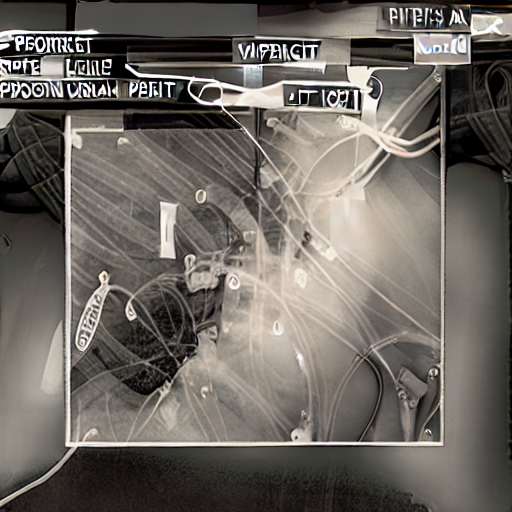

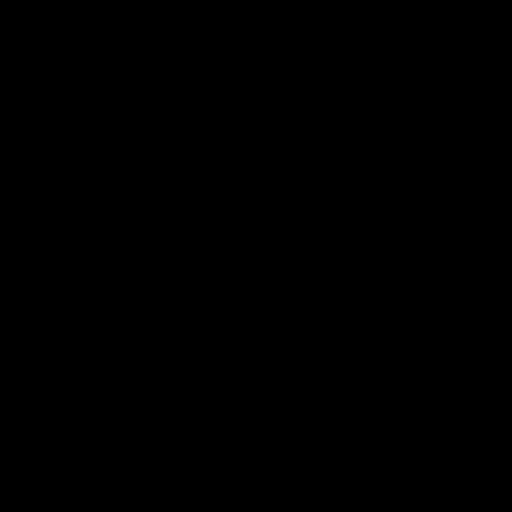

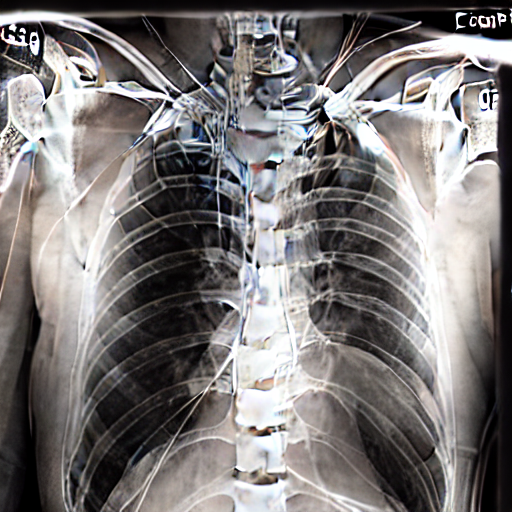

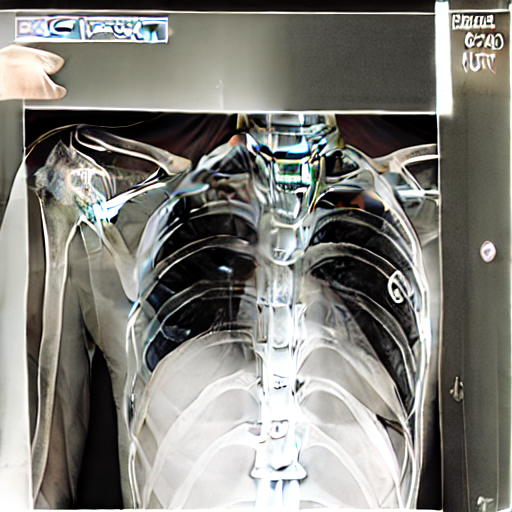

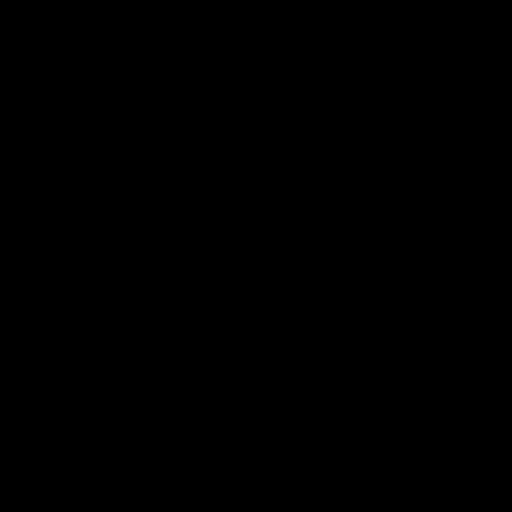

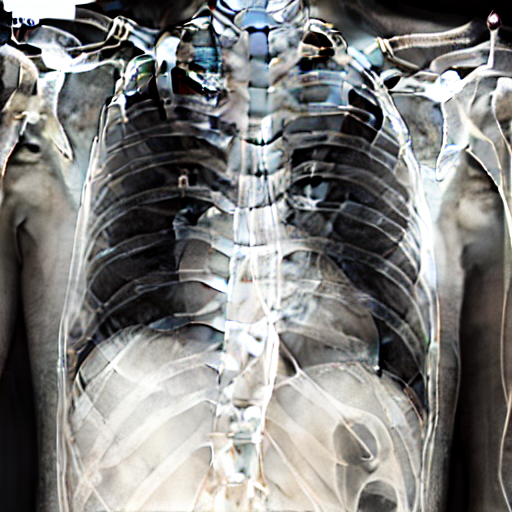

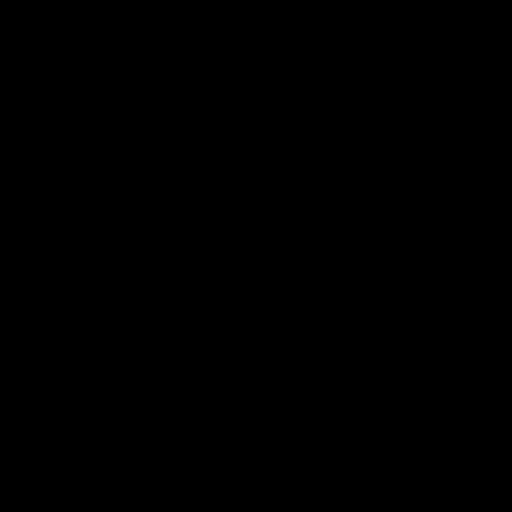

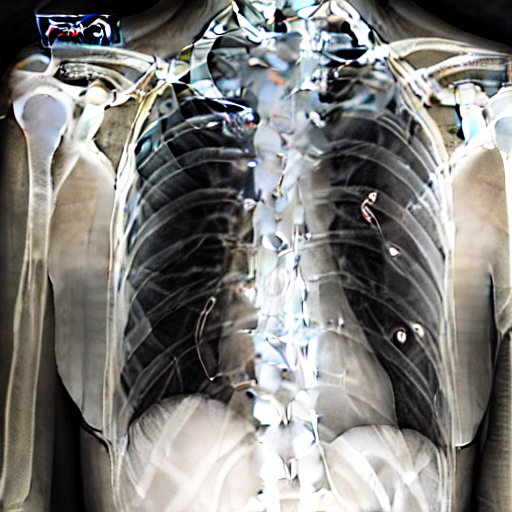

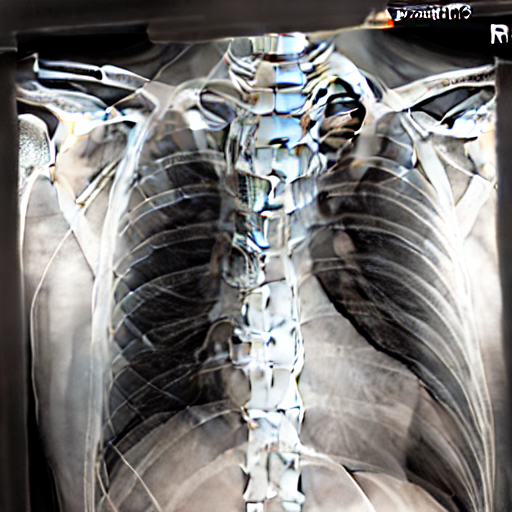

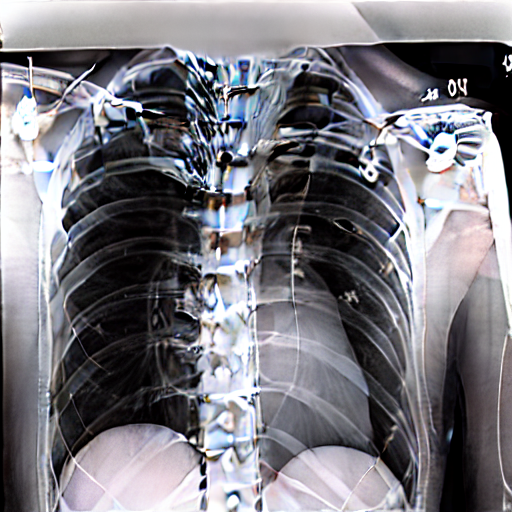

In [5]:
import torch
from peft import get_peft_model, LoraConfig

def load_lora_weights(pipe, lora_path):
    """
    Load LoRA fine-tuned weights into the UNet of a Stable Diffusion pipeline.

    Args:
        pipe: A StableDiffusionPipeline instance.
        lora_path: Path to the saved LoRA UNet weights (.pt file).
    """
    # Define the same LoRA configuration used during training
    lora_config = LoraConfig(
        r=4,
        lora_alpha=16,
        target_modules=["to_q", "to_k", "to_v"],
        lora_dropout=0.1,
        bias="none"
    )

    # Wrap the UNet with LoRA and load the fine-tuned weights
    pipe.unet = get_peft_model(pipe.unet, lora_config)
    pipe.unet.load_state_dict(torch.load(lora_path), strict=False)
    pipe.unet.eval()
    print(f"✅ Loaded LoRA weights from: {lora_path}")

# Example usage
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float32)
pipe.to("cuda")

# Provide your saved path here
#original path
#ORA_WEIGHTS_PATH = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/LORA_prompt_guided_fine_tuning_stable_diffusion_model/lora_unet_epoch_28.pt"

#rough path
LORA_WEIGHTS_PATH = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2//LORA_prompt_guided_fine_tuning_stable_diffusion_model/lora_unet_epoch_146.pt"

load_lora_weights(pipe, LORA_WEIGHTS_PATH)

prompt = "Chest X-ray of a patient showing alot of medical support devices such as pacemaker"
#prompt = "Chest X-ray of a 50 years old male black patient with medical support devices scuh as pacemaker on lungs"
images = pipe(
    prompt,
    num_inference_steps=40,
    guidance_scale=8.5,
    num_images_per_prompt=10  # Generate number images at once
).images

from IPython.display import display

for img in images:
    display(img)

In [1]:
import torch
from peft import get_peft_model, LoraConfig
from diffusers import StableDiffusionPipeline, DDIMScheduler

# Step 1: Load the pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", 
    torch_dtype=torch.float32
)
pipe.to("cuda")

# Step 2: Load LoRA weights
def load_lora_weights(pipe, lora_path):
    lora_config = LoraConfig(
        r=4,
        lora_alpha=16,
        target_modules=["to_q", "to_k", "to_v"],
        lora_dropout=0.1,
        bias="none"
    )
    pipe.unet = get_peft_model(pipe.unet, lora_config)
    pipe.unet.load_state_dict(torch.load(lora_path), strict=False)
    pipe.unet.eval()
    print(f"✅ Loaded LoRA weights from: {lora_path}")

LORA_WEIGHTS_PATH = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2//LORA_prompt_guided_fine_tuning_stable_diffusion_model/lora_unet_epoch_146.pt"
load_lora_weights(pipe, LORA_WEIGHTS_PATH)

# Step 3: Replace scheduler with DDIM
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe.scheduler.set_timesteps(num_inference_steps=100)

# Step 4: Prompt and classifier-free guidance
prompt = "Chest X-ray of a patient showing medical support devices like a pacemaker"
guidance = 8.5

prompt_embeds = pipe._encode_prompt(
    prompt, 
    device=pipe.device, 
    num_images_per_prompt=1, 
    do_classifier_free_guidance=True
)

# Step 5: Initialize latent space
latents = torch.randn(
    (1, pipe.unet.in_channels, pipe.unet.sample_size, pipe.unet.sample_size),
    device=pipe.device,
    dtype=pipe.unet.dtype
)

# Step 6: Run manual denoising up to x700 (i.e., t=300 if timesteps are descending)
for i, t in enumerate(pipe.scheduler.timesteps):
    latent_model_input = torch.cat([latents] * 2)
    latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

    noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=prompt_embeds).sample
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    noise_pred = noise_pred_uncond + guidance * (noise_pred_text - noise_pred_uncond)

    latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample  # Fixed index

    if i == 30:  # Stop at X_700
        break


# Step 7: Decode latent to image
with torch.no_grad():
    image = pipe.decode_latents(latents)
    image = pipe.numpy_to_pil(image)[0]

# Step 8: Display
from IPython.display import display
display(image)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Loaded LoRA weights from: /mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2//LORA_prompt_guided_fine_tuning_stable_diffusion_model/lora_unet_epoch_146.pt


/home/dawood/lab2_rotaion/.conda/lib/python3.12/site-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:308: FutureWarning: `_encode_prompt()` is deprecated and it will be removed in a future version. Use `encode_prompt()` instead. Also, be aware that the output format changed from a concatenated tensor to a tuple.
  deprecate("_encode_prompt()", "1.0.0", deprecation_message, standard_warn=False)
/home/dawood/lab2_rotaion/.conda/lib/python3.12/site-packages/peft/tuners/lora/model.py:363: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  return getattr(self.model, name)


OutOfMemoryError: CUDA out of memory. Tried to allocate 40.00 MiB. GPU 0 has a total capacity of 79.32 GiB of which 39.00 MiB is free. Including non-PyTorch memory, this process has 79.28 GiB memory in use. Of the allocated memory 78.72 GiB is allocated by PyTorch, and 65.78 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)